In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

In [2]:
# Parameters

E=1
dm2 = 1
theta =0.195
sin_2th   = np.sin(2*theta)
cos_2th   = np.cos(2*theta)
omega = dm2/(4.0*E)

bx = omega * np.sin(2 * theta)
by = 0.0
bz = -omega * np.cos(2 * theta)

# number of nu #
N = 4

In [3]:
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J

In [4]:
# -------------------------------------------------
# Add vacuum evolution to an existing circuit
# -------------------------------------------------
def add_vacuum_evolution(qc, n, bx, by, bz, N):
    """
    Add n first-order vacuum steps to the circuit.

    Each step applies:
        exp[-i (bx X_i + by Y_i + bz Z_i)]
    approximately as
        RX(2bx) RY(2by) RZ(2bz)
    on every qubit i.
    """
    for _ in range(n):
        for q in range(N):
            qc.rx(2.0 * bx, q)
            qc.ry(2.0 * by, q)
            qc.rz(2.0 * bz, q)


# -------------------------------------------------
# Add interaction evolution to an existing circuit
# -------------------------------------------------
def add_interaction_evolution(qc, n, J, N):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply
        exp[-i Jij (XX + YY + ZZ)]
    as
        RXX(2 Jij) RYY(2 Jij) RZZ(2 Jij)
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 2.0 * J[i, j]
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

In [5]:
def build_full_circuit(qc0, n, bx, by, bz, J, N):
    qc = qc0.copy()

    add_vacuum_evolution(qc, n, bx, by, bz, N)
    add_interaction_evolution(qc, n, J, N)

    qc.measure(range(N), range(N))
    return qc

In [6]:
# Interaction matrix
J = interaction_matrix(N, dm2, E)

# Initial state prepared outside
qc0 = QuantumCircuit(N, N)
qc0.x(2)# example: qubit 1 is nu_mu, others nu_e
qc0.x(3)

# Build evolved circuit
qc = build_full_circuit(qc0, n=10, bx=bx, by=by, bz=bz, J=J, N=N)

print(qc.decompose())

global phase: 2.9659
     ┌──────────────┐  ┌──────────┐  ┌──────────────┐┌──────────────┐»
q_0: ┤ R(0.19009,0) ├──┤ R(0,π/2) ├──┤ U1(-0.46245) ├┤ R(0.19009,0) ├»
     ├──────────────┤  ├──────────┤  ├──────────────┤├──────────────┤»
q_1: ┤ R(0.19009,0) ├──┤ R(0,π/2) ├──┤ U1(-0.46245) ├┤ R(0.19009,0) ├»
     └┬───────────┬─┘┌─┴──────────┴─┐└─┬──────────┬─┘├──────────────┤»
q_2: ─┤ U3(π,0,π) ├──┤ R(0.19009,0) ├──┤ R(0,π/2) ├──┤ U1(-0.46245) ├»
      ├───────────┤  ├──────────────┤  ├──────────┤  ├──────────────┤»
q_3: ─┤ U3(π,0,π) ├──┤ R(0.19009,0) ├──┤ R(0,π/2) ├──┤ U1(-0.46245) ├»
      └───────────┘  └──────────────┘  └──────────┘  └──────────────┘»
c: 4/════════════════════════════════════════════════════════════════»
                                                                     »
«       ┌──────────┐  ┌──────────────┐┌──────────────┐  ┌──────────┐  »
«q_0: ──┤ R(0,π/2) ├──┤ U1(-0.46245) ├┤ R(0.19009,0) ├──┤ R(0,π/2) ├──»
«       ├──────────┤  ├──────────────┤├──────────────┤

In [7]:
# backend = AerSimulator()
# shots = 4096
# n_steps_max = 40

# for n in range(n_steps_max + 1):
#     qc = build_full_circuit(qc0, n=n, bx=bx, by=by, bz=bz, J=J, N=N)
#     tqc = transpile(qc, backend)
#     counts = backend.run(tqc, shots=shots).result().get_counts()
#     print(f"t = {n:2d}, counts = {counts}")

In [8]:
P_nue_q0 = []
P_numu_q1 = []
P_nue_q0_INV = []
P_numu_q1_INV = []

times = []

backend = AerSimulator()
shots = 4096
n_steps_max = 40

for n in range(n_steps_max + 1):
    qc = build_full_circuit(qc0, n=n, bx=bx, by=by, bz=bz, J=J, N=N)
    tqc = transpile(qc, backend)
    counts = backend.run(tqc, shots=shots).result().get_counts()

    p0_nue = 0.0
    p1_numu = 0.0

    for bitstring, c in counts.items():
        # rightmost bit is qubit 0, next is qubit 1
        q0 = int(bitstring[-1])
        q1 = int(bitstring[-2])

        if q0 == 0:
            p0_nue += c / shots
        if q1 == 1:
            p1_numu += c / shots

    times.append(n)
    P_nue_q0.append(p0_nue)
    P_numu_q1.append(p1_numu)
    P_nue_q0_INV.append(1-p0_nue)
    P_numu_q1_INV.append(1-p1_numu)

#     print(f"t = {n:2d}, counts = {counts}, P(q0=nu_e) = {p0_nue:.4f}, P(q1=nu_mu) = {p1_numu:.4f}")

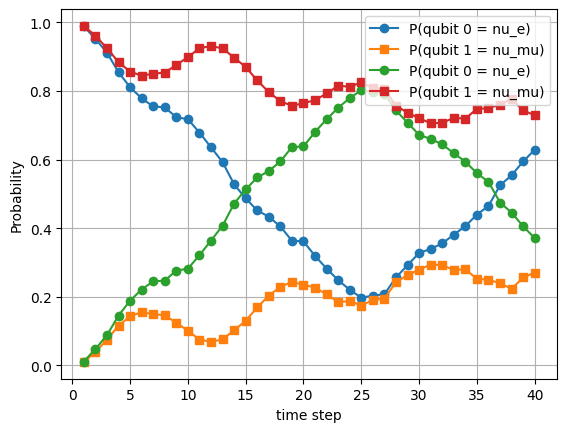

In [9]:
# plt.plot(times[1:], P_nue_q0_INV[1:], marker='o', label='P_inv(qubit 0 = nu_e)')
# plt.plot(times[1:], P_numu_q1_INV[1:], marker='s', label='P_inv(qubit 1 = nu_mu)')
plt.plot(times[1:], P_nue_q0[1:], marker='o', label='P(qubit 0 = nu_e)')
plt.plot(times[1:], P_numu_q1[1:], marker='s', label='P(qubit 1 = nu_mu)')
plt.plot(times[1:], P_nue_q0_INV[1:], marker='o', label='P(qubit 0 = nu_e)')
plt.plot(times[1:], P_numu_q1_INV[1:], marker='s', label='P(qubit 1 = nu_mu)')
plt.xlabel('time step')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator

initial_bits = [0, 0, 1, 1]

P_inv = [[] for _ in range(N)]
times = []

backend = AerSimulator()
shots = 4096
n_steps_max = 40

for n in range(n_steps_max + 1):
    qc=qc0.copy()
    #add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)
    add_interaction_evolution(qc, n=n, J=J, N=N)
#     tqc = transpile(qc, backend)
#     counts = backend.run(tqc, shots=shots).result().get_counts()

    qc.measure(range(N), range(N))

    tqc = transpile(qc, backend)
    counts = backend.run(tqc, shots=shots).result().get_counts()

    p_inv_t = [0.0] * N

    for bitstring, c in counts.items():
        prob = c / shots

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    times.append(n)

    for q in range(N):
        P_inv[q].append(p_inv_t[q])

    print(
        f"t = {n:2d} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

t =  0 | q0_inv = 0.0000, q1_inv = 0.0000, q2_inv = 0.0000, q3_inv = 0.0000
t =  1 | q0_inv = 0.0017, q1_inv = 0.0007, q2_inv = 0.0005, q3_inv = 0.0020
t =  2 | q0_inv = 0.0103, q1_inv = 0.0027, q2_inv = 0.0032, q3_inv = 0.0098
t =  3 | q0_inv = 0.0278, q1_inv = 0.0039, q2_inv = 0.0063, q3_inv = 0.0254
t =  4 | q0_inv = 0.0442, q1_inv = 0.0063, q2_inv = 0.0076, q3_inv = 0.0430
t =  5 | q0_inv = 0.0779, q1_inv = 0.0117, q2_inv = 0.0151, q3_inv = 0.0745
t =  6 | q0_inv = 0.0994, q1_inv = 0.0200, q2_inv = 0.0183, q3_inv = 0.1011
t =  7 | q0_inv = 0.1360, q1_inv = 0.0261, q2_inv = 0.0259, q3_inv = 0.1362
t =  8 | q0_inv = 0.1812, q1_inv = 0.0349, q2_inv = 0.0417, q3_inv = 0.1743
t =  9 | q0_inv = 0.2151, q1_inv = 0.0376, q2_inv = 0.0381, q3_inv = 0.2146
t = 10 | q0_inv = 0.2659, q1_inv = 0.0515, q2_inv = 0.0505, q3_inv = 0.2668
t = 11 | q0_inv = 0.3176, q1_inv = 0.0559, q2_inv = 0.0537, q3_inv = 0.3198
t = 12 | q0_inv = 0.3555, q1_inv = 0.0642, q2_inv = 0.0608, q3_inv = 0.3589
t = 13 | q0_

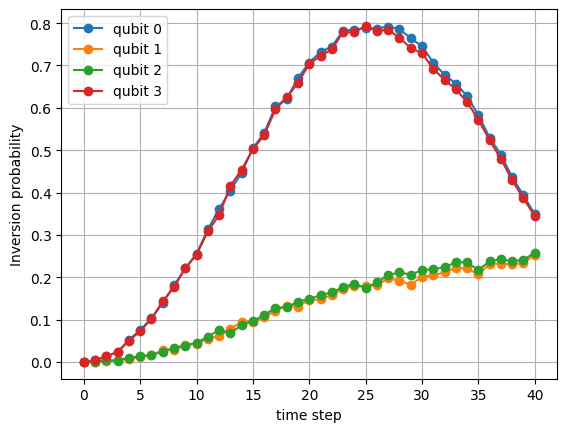

In [11]:
for q in range(N):
    plt.plot(times, P_inv[q], marker='o', label=f'qubit {q}')

plt.xlabel('time step')
plt.ylabel('Inversion probability')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
### Drawing quantum circuit dor one first order Trotter step
qc=QuantumCircuit(2,2)
qc.x(1)
qc.draw('mpl')
add_interaction_evolution(qc, n=1, J=J, N=2)
#qc.draw('mpl')
qc.decompose()
qc_dec.draw(output="latex_source", filename="circuit.tex")

print(qc_dec.draw(output="text"))

         ┌───┐                                    ┌───┐┌─────────┐     »
q_0: ────┤ H ├───────────■─────────────────────■──┤ H ├┤ Rx(π/2) ├──■──»
     ┌───┴───┴───┐┌───┐┌─┴─┐┌───────────────┐┌─┴─┐├───┤├─────────┤┌─┴─┐»
q_1: ┤ U3(π,0,π) ├┤ H ├┤ X ├┤ Rz(0.0056401) ├┤ X ├┤ H ├┤ Rx(π/2) ├┤ X ├»
     └───────────┘└───┘└───┘└───────────────┘└───┘└───┘└─────────┘└───┘»
c: 2/══════════════════════════════════════════════════════════════════»
                                                                       »
«                           ┌──────────┐                           
«q_0: ───────────────────■──┤ Rx(-π/2) ├──■─────────────────────■──
«     ┌───────────────┐┌─┴─┐├──────────┤┌─┴─┐┌───────────────┐┌─┴─┐
«q_1: ┤ Rz(0.0056401) ├┤ X ├┤ Rx(-π/2) ├┤ X ├┤ Rz(0.0056401) ├┤ X ├
«     └───────────────┘└───┘└──────────┘└───┘└───────────────┘└───┘
«c: 2/═════════════════════════════════════════════════════════════
«                                                                  
